Importem llibreries y gràfica

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuració estètica
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")



Importem DF

In [2]:
RRHH = pd.read_csv(r"C:\Users\PC\Desktop\ProjecteData\Equip_15\Data\RRHH_150925_clean.csv")

Total d'hores d'absentisme en un any

In [3]:
# Total d'hores d'absentisme en un any
total_hores_absentisme = RRHH['Absenteeism_hours'].sum()
print(f"Total d'hores d'absentisme anual: {total_hores_absentisme} hores")

# Mitjana d'hores d'absentisme per empleat
mitjana_absentisme_empleat = RRHH.groupby('ID')['Absenteeism_hours'].sum().mean()
print(f"Mitjana d'hores d'absentisme per empleat: {mitjana_absentisme_empleat:.2f} hores")

# Taxa d'absentisme (assumint 8 hores de treball per dia i 230 dies laborables anuals)
hores_treball_anuals = 36 * 8 * 230  # 36 empleats × 8 hores × 230 dies
taxa_absentisme = (total_hores_absentisme / hores_treball_anuals) * 100
print(f"Taxa d'absentisme: {taxa_absentisme:.2f}%")

Total d'hores d'absentisme anual: 5043 hores
Mitjana d'hores d'absentisme per empleat: 140.08 hores
Taxa d'absentisme: 7.61%


Mitjana d'hores d'absentisme per empleat per any

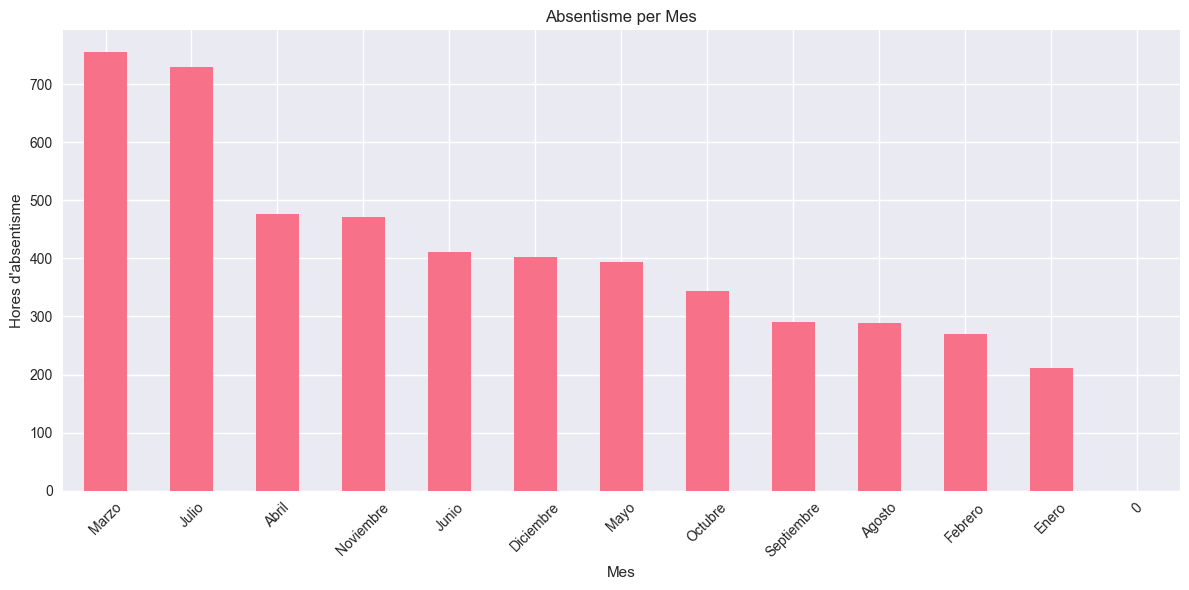

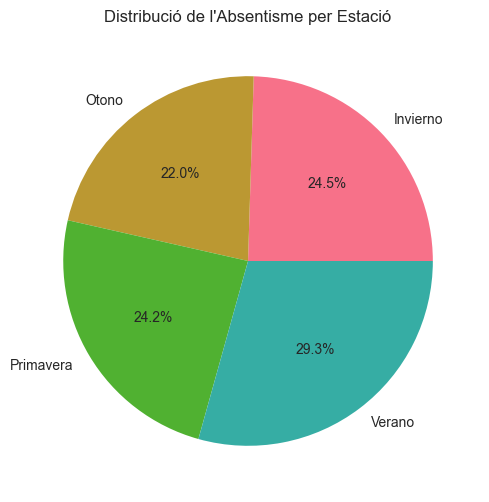

In [4]:
# Absentisme per mes
absentisme_mensual = RRHH.groupby('Month_absence')['Absenteeism_hours'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
absentisme_mensual.plot(kind='bar')
plt.title('Absentisme per Mes')
plt.xlabel('Mes')
plt.ylabel('Hores d\'absentisme')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Absentisme per estació
absentisme_estacional = RRHH.groupby('Seasons')['Absenteeism_hours'].sum()

plt.figure(figsize=(8, 6))
absentisme_estacional.plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribució de l\'Absentisme per Estació')
plt.ylabel('')
plt.show()

Taxa d'absentisme

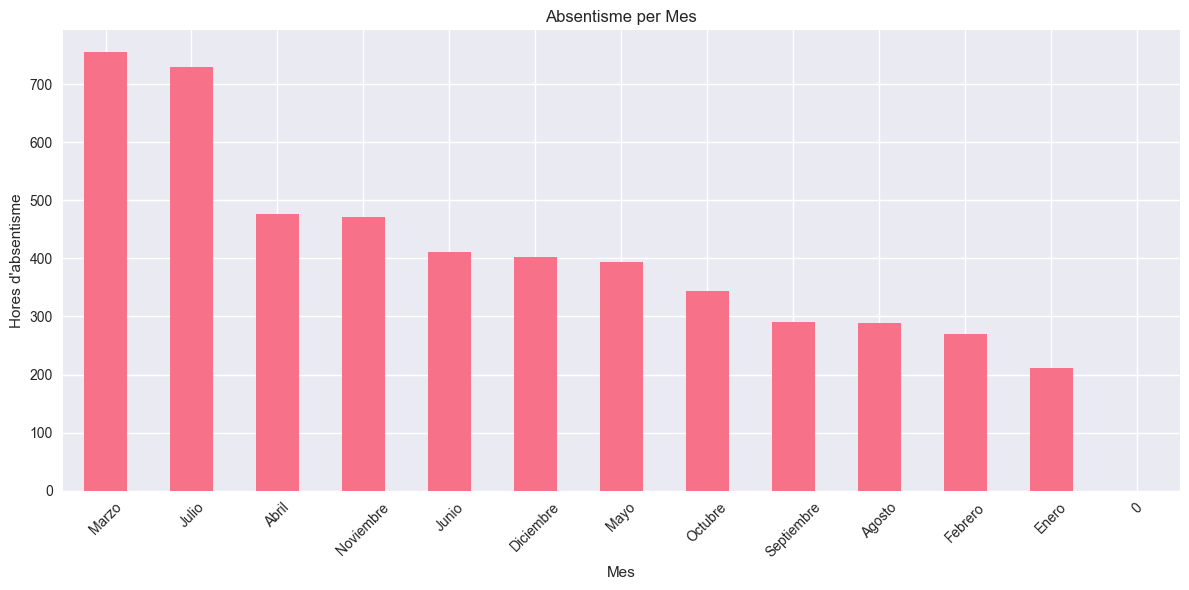

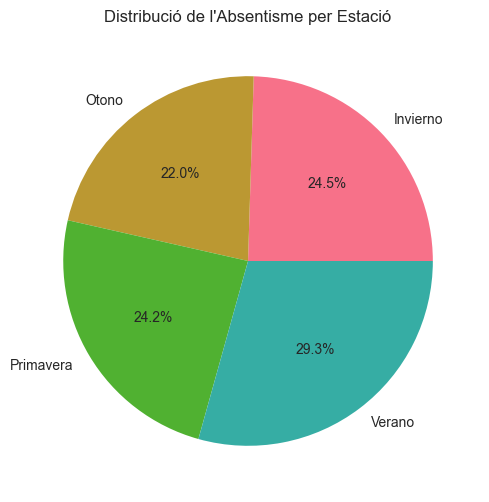

In [5]:
# Absentisme per mes
absentisme_mensual = RRHH.groupby('Month_absence')['Absenteeism_hours'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
absentisme_mensual.plot(kind='bar')
plt.title('Absentisme per Mes')
plt.xlabel('Mes')
plt.ylabel('Hores d\'absentisme')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Absentisme per estació
absentisme_estacional = RRHH.groupby('Seasons')['Absenteeism_hours'].sum()

plt.figure(figsize=(8, 6))
absentisme_estacional.plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribució de l\'Absentisme per Estació')
plt.ylabel('')
plt.show()

Anàlisi per Motiu d'Absència. Top 10 Motius d'Absentisme per Hores

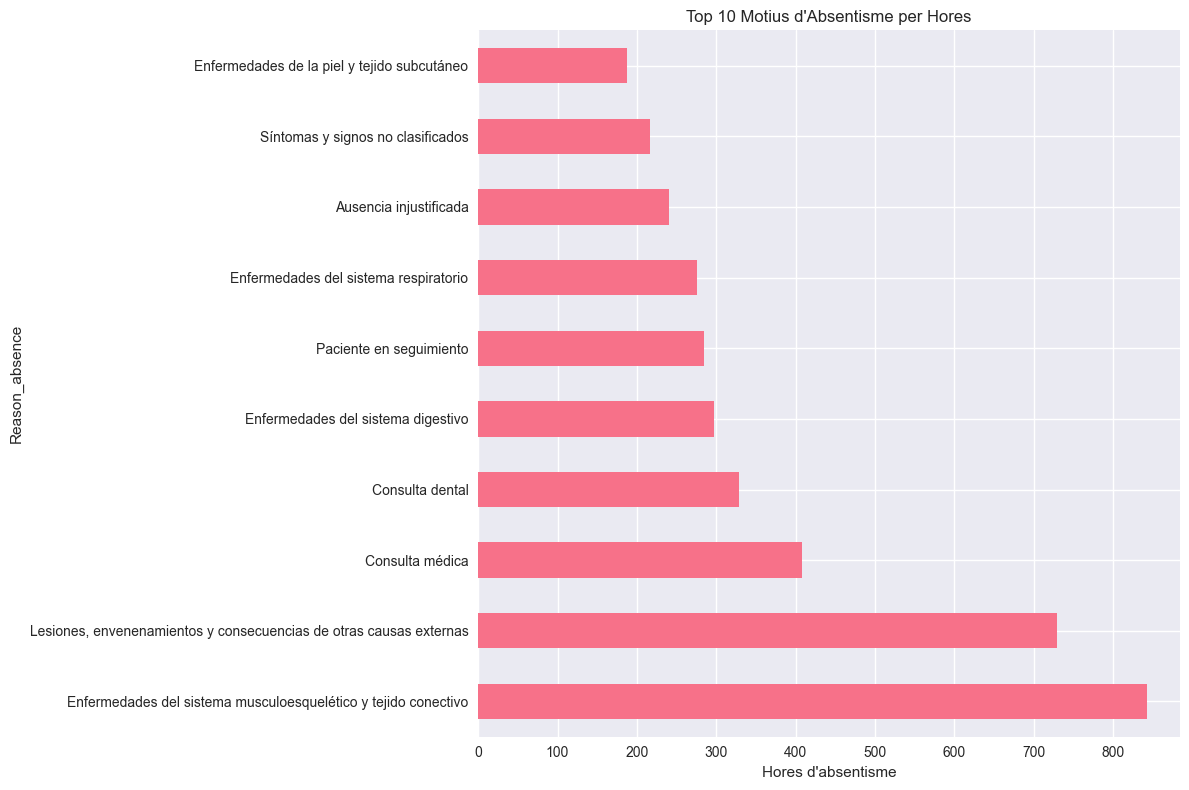

In [6]:
# Diccionari de motius
reason_absence_dict = {
    0: "Sin especificar / Otros",
    1: "Enfermedades infecciosas y parasitarias",
    2: "Neoplasias (tumores)",
    3: "Enfermedades de la sangre y órganos hematopoyéticos",
    4: "Enfermedades endocrinas, nutricionales y metabólicas",
    5: "Trastornos mentales y del comportamiento",
    6: "Enfermedades del sistema nervioso",
    7: "Enfermedades del ojo y sus anexos",
    8: "Enfermedades del oído y la apófisis mastoides",
    9: "Enfermedades del sistema circulatorio",
    10: "Enfermedades del sistema respiratorio",
    11: "Enfermedades del sistema digestivo",
    12: "Enfermedades de la piel y tejido subcutáneo",
    13: "Enfermedades del sistema musculoesquelético y tejido conectivo",
    14: "Enfermedades del sistema genitourinario",
    15: "Embarazo, parto y puerperio",
    16: "Condiciones originadas en el período perinatal",
    17: "Malformaciones congénitas y anomalías cromosómicas",
    18: "Síntomas y signos no clasificados",
    19: "Lesiones, envenenamientos y consecuencias de otras causas externas",
    20: "Causas externas de morbilidad y mortalidad",
    21: "Factores que influyen en el estado de salud",
    22: "Paciente en seguimiento",
    23: "Consulta médica",
    24: "Donación de sangre",
    25: "Examen de laboratorio",
    26: "Ausencia injustificada",
    27: "Fisioterapia",
    28: "Consulta dental"
}

# Absentisme per motiu
absentisme_motiu = RRHH.groupby('Reason_absence')['Absenteeism_hours'].sum().sort_values(ascending=False)

# Convertir codis a descripcions
absentisme_motiu.index = absentisme_motiu.index.map(lambda x: reason_absence_dict.get(x, f"Motiu {x}"))

plt.figure(figsize=(12, 8))
absentisme_motiu.head(10).plot(kind='barh')
plt.title('Top 10 Motius d\'Absentisme per Hores')
plt.xlabel('Hores d\'absentisme')
plt.tight_layout()
plt.show()

Anàlisi per Perfil de l'Empleat

Correlació entre Age i absentisme: 0.066


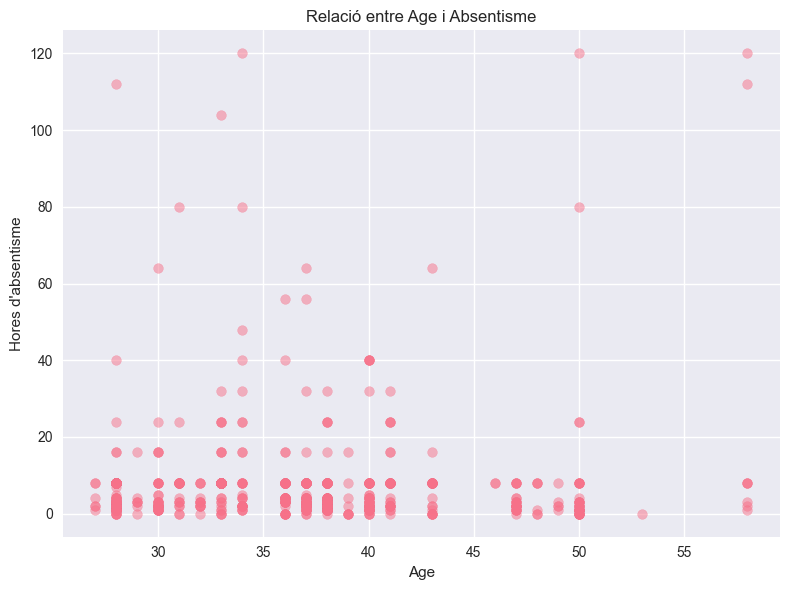

Correlació entre Son i absentisme: 0.102


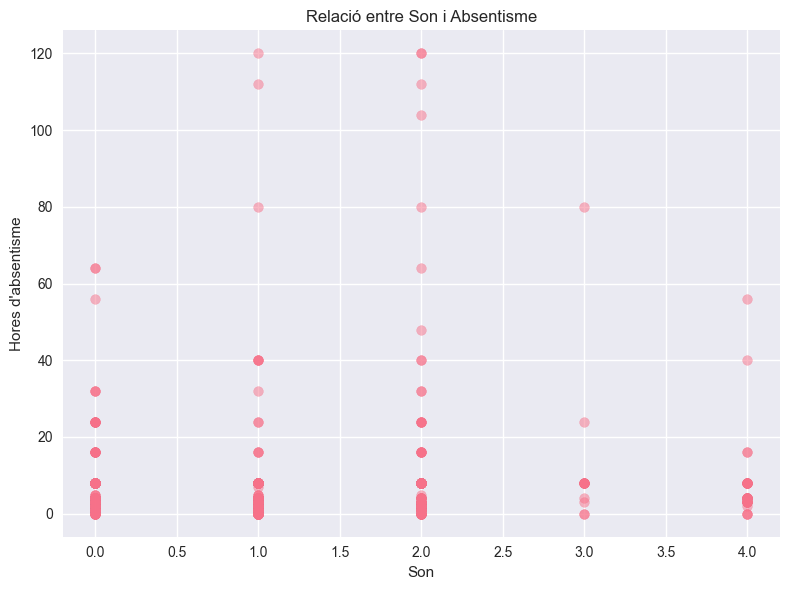

Correlació entre Pet i absentisme: -0.036


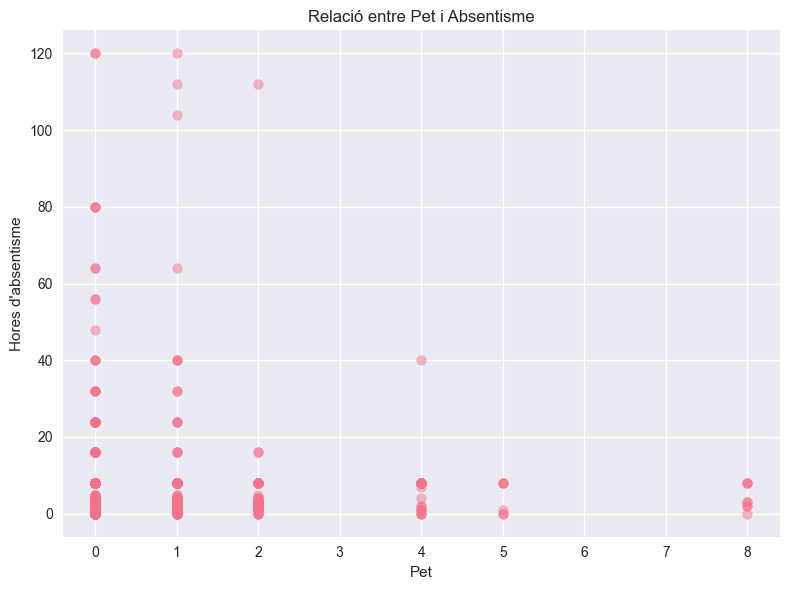

Correlació entre Social_drinker i absentisme: 0.068


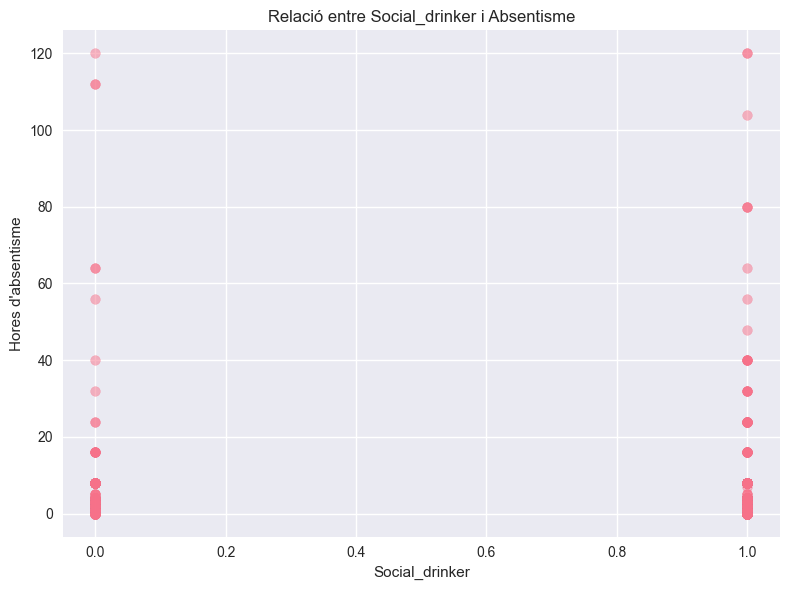

Correlació entre Social_smoker i absentisme: -0.014


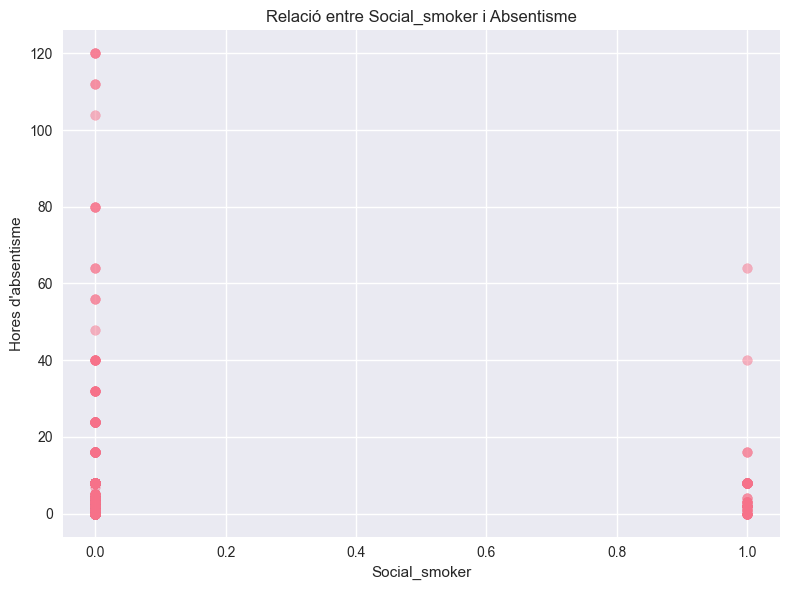

In [7]:
# Relació entre variables sociodemogràfiques i absentisme
variables_socio = ['Age', 'Son', 'Pet', 'Social_drinker', 'Social_smoker']

for var in variables_socio:
    if RRHH[var].dtype == 'object':  # Variables categòriques
        grouped = RRHH.groupby(var)['Absenteeism_hours'].mean()
        print(f"\nAbsentisme mitjà per {var}:")
        print(grouped)
        
        plt.figure(figsize=(8, 6))
        grouped.plot(kind='bar')
        plt.title(f'Absentisme mitjà per {var}')
        plt.ylabel('Hores mitjanes d\'absentisme')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    else:  # Variables numèriques
        correlation = RRHH[var].corr(RRHH['Absenteeism_hours'])
        print(f"Correlació entre {var} i absentisme: {correlation:.3f}")
        
        plt.figure(figsize=(8, 6))
        plt.scatter(RRHH[var], RRHH['Absenteeism_hours'], alpha=0.5)
        plt.title(f'Relació entre {var} i Absentisme')
        plt.xlabel(var)
        plt.ylabel('Hores d\'absentisme')
        plt.tight_layout()
        plt.show()

Anàlisi de Factors Laborals

In [8]:
# Factors laborals
factors_laborals = ['Distance_Residence_Work', 'Work_load_Average_day', 'Service_time', 'Disciplinary_failure']

for factor in factors_laborals:
    if RRHH[factor].dtype == 'object':  # Variables categòriques
        grouped = RRHH.groupby(factor)['Absenteeism_hours'].mean()
        print(f"\nAbsentisme mitjà per {factor}:")
        print(grouped)
    else:  # Variables numèriques
        correlation = RRHH[factor].corr(RRHH['Absenteeism_hours'])
        print(f"Correlació entre {factor} i absentisme: {correlation:.3f}")

# Test d'hipòtesi per comparar fumadors i no fumadors
fumadors = RRHH[RRHH['Social_smoker'] == '1']['Absenteeism_hours']
no_fumadors = RRHH[RRHH['Social_smoker'] == '0']['Absenteeism_hours']

t_stat, p_value = stats.ttest_ind(fumadors, no_fumadors, nan_policy='omit')
print(f"\nT-test entre fumadors i no fumadors: t={t_stat:.3f}, p={p_value:.3f}")

if p_value < 0.05:
    print("Hi ha una diferència significativa en l'absentisme entre fumadors i no fumadors")
else:
    print("No hi ha una diferència significativa en l'absentisme entre fumadors i no fumadors")

Correlació entre Distance_Residence_Work i absentisme: -0.085
Correlació entre Work_load_Average_day i absentisme: 0.020
Correlació entre Service_time i absentisme: 0.025
Correlació entre Disciplinary_failure i absentisme: -0.129

T-test entre fumadors i no fumadors: t=nan, p=nan
No hi ha una diferència significativa en l'absentisme entre fumadors i no fumadors


c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


Visualització de Correlacions

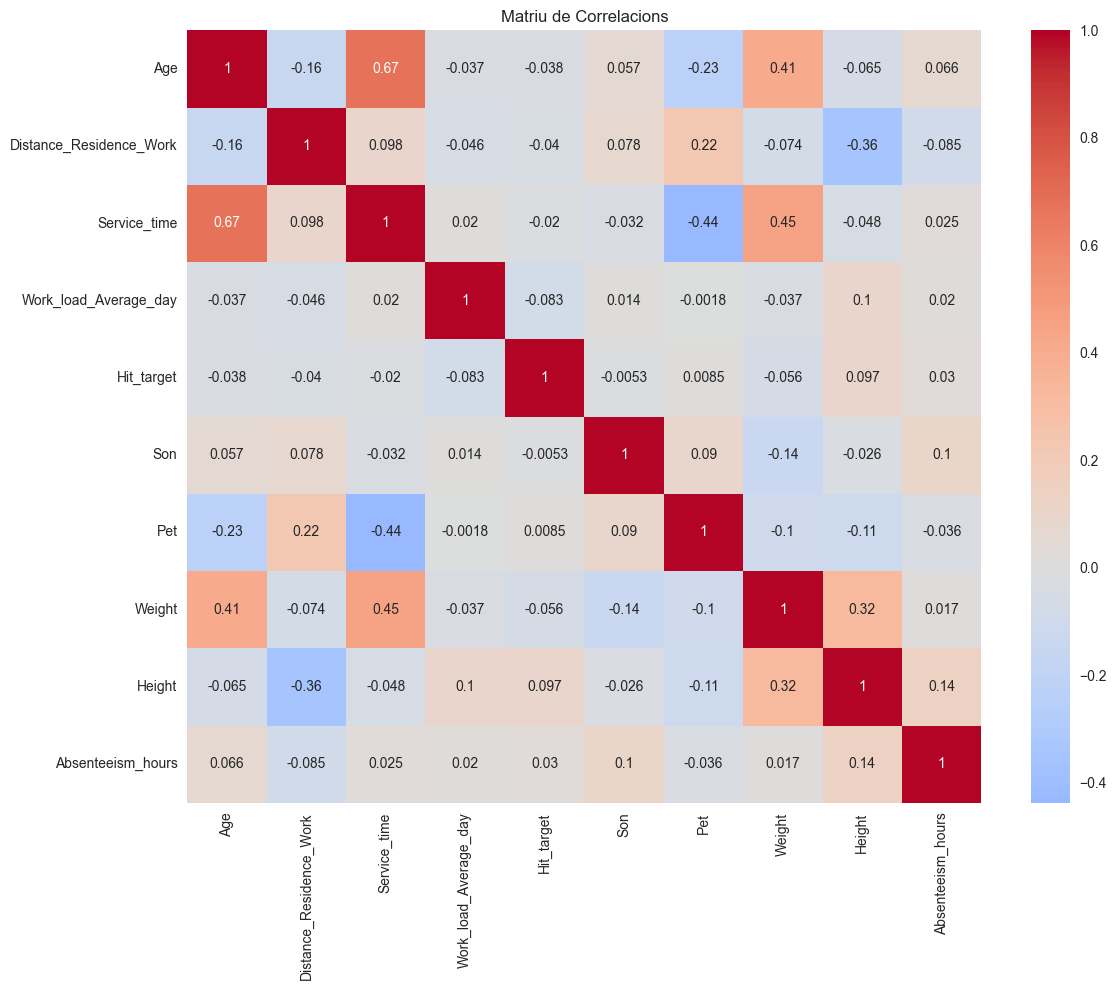

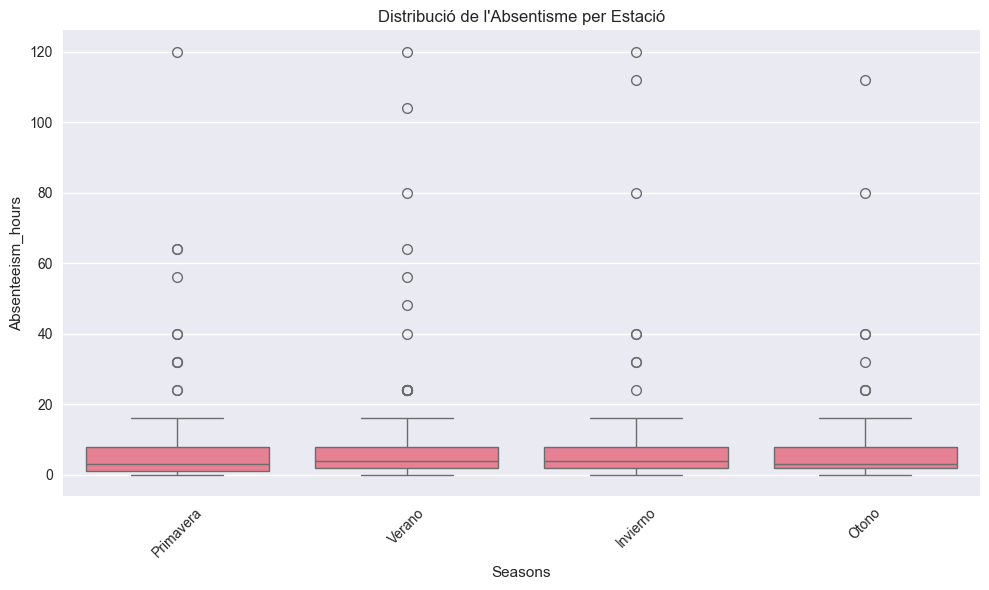

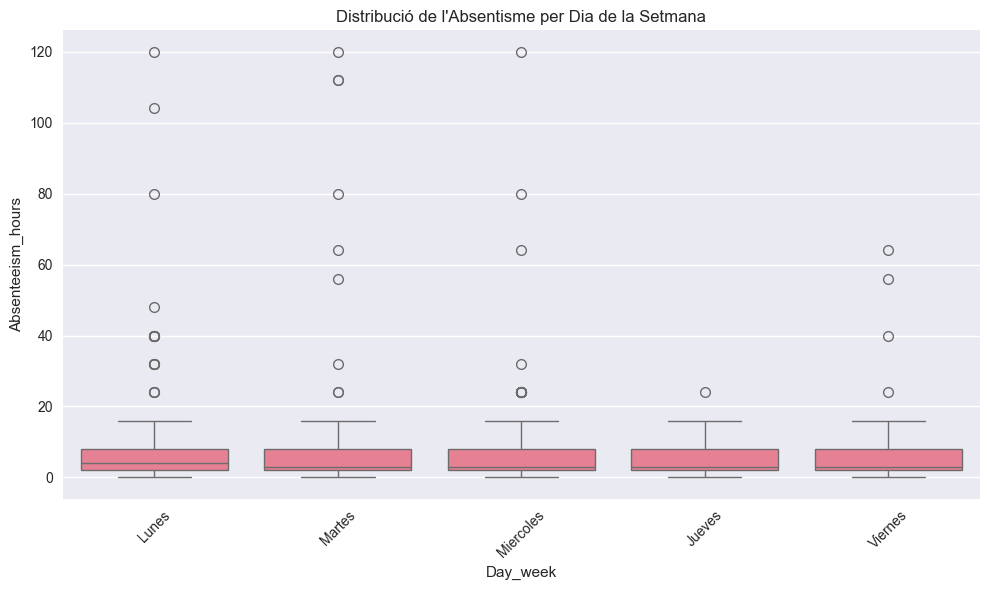

In [9]:
# Heatmap de correlacions
variables_numeriques = ['Age', 'Distance_Residence_Work', 'Service_time', 
                       'Work_load_Average_day', 'Hit_target', 'Son', 'Pet', 
                       'Weight', 'Height', 'Absenteeism_hours']

correlation_matrix = RRHH[variables_numeriques].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Matriu de Correlacions')
plt.tight_layout()
plt.show()

# Boxplot d'absentisme per estació
plt.figure(figsize=(10, 6))
sns.boxplot(x='Seasons', y='Absenteeism_hours', data=RRHH)
plt.title('Distribució de l\'Absentisme per Estació')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Boxplot d'absentisme per dia de la setmana
plt.figure(figsize=(10, 6))
sns.boxplot(x='Day_week', y='Absenteeism_hours', data=RRHH, order=['Lunes', 'Martes', 'Miercoles', 'Jueves', 'Viernes'])
plt.title('Distribució de l\'Absentisme per Dia de la Setmana')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Sistema de Predicció (Model Bàsic)

Error Absolut Mitjà (MAE): 6.21
Arrel de l'Error Quadràtic Mitjà (RMSE): 14.23


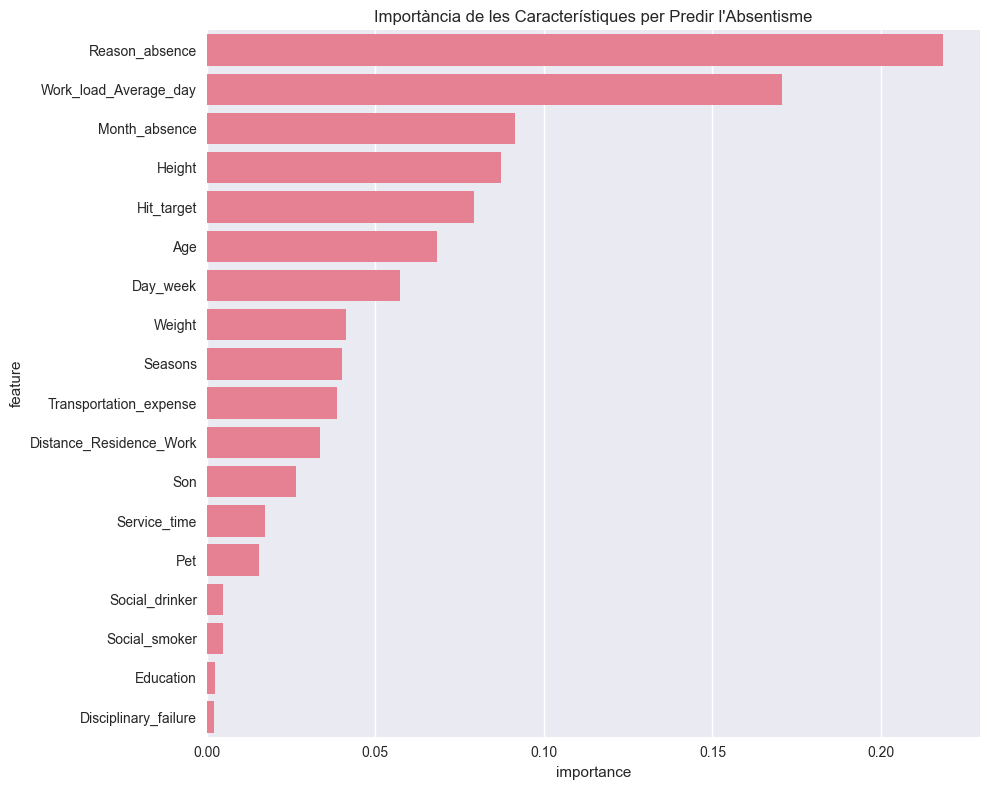

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Preparar les dades per a la predicció
# Convertir variables categòriques a numèriques
rrhh_model = RRHH.copy()
categorical_cols = ['Month_absence', 'Day_week', 'Seasons', 'Disciplinary_failure', 
                   'Education', 'Social_drinker', 'Social_smoker']

for col in categorical_cols:
    rrhh_model[col] = rrhh_model[col].astype('category').cat.codes

# Seleccionar característiques i variable objectiu
features = ['Reason_absence', 'Month_absence', 'Day_week', 'Seasons',
           'Transportation_expense', 'Distance_Residence_Work', 'Service_time',
           'Age', 'Work_load_Average_day', 'Hit_target', 'Disciplinary_failure',
           'Education', 'Son', 'Social_drinker', 'Social_smoker', 'Pet',
           'Weight', 'Height']

X = rrhh_model[features]
y = rrhh_model['Absenteeism_hours']

# Dividir les dades
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar el model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Avaluar el model
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Error Absolut Mitjà (MAE): {mae:.2f}")
print(f"Arrel de l'Error Quadràtic Mitjà (RMSE): {rmse:.2f}")

# Importància de les característiques
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=feature_importance)
plt.title('Importància de les Característiques per Predir l\'Absentisme')
plt.tight_layout()
plt.show()

Recomanacions basades en l'anàlisi

In [11]:
# Identificar mesos amb major absentisme per planificar recursos
mesos_crítics = absentisme_mensual.head(3)
print("Mesos amb major absentisme (hores totals):")
for mes, hores in mesos_crítics.items():
    print(f"{mes}: {hores} hores")

# Identificar perfil d'empleats amb major absentisme
absentisme_per_empleat = RRHH.groupby('ID')['Absenteeism_hours'].sum().sort_values(ascending=False)
empleats_al_risc = absentisme_per_empleat.head(5)
print("\nEmpleats amb major absentisme (hores totals):")
for empleat, hores in empleats_al_risc.items():
    print(f"Empleat {empleat}: {hores} hores")

# Recomanació per a la creació d'un pool de treballadors temporals
print("\nRecomanació: Es recomana crear un pool de treballadors temporals per cobrir")
print("les necessitats durant els mesos d'alt absentisme, especialment a:")
for mes in mesos_crítics.index:
    print(f"- {mes}")

Mesos amb major absentisme (hores totals):
Marzo: 755 hores
Julio: 730 hores
Abril: 476 hores

Empleats amb major absentisme (hores totals):
Empleat 14: 476 hores
Empleat 11: 450 hores
Empleat 3: 444 hores
Empleat 28: 343 hores
Empleat 34: 333 hores

Recomanació: Es recomana crear un pool de treballadors temporals per cobrir
les necessitats durant els mesos d'alt absentisme, especialment a:
- Marzo
- Julio
- Abril
